In [2]:
load_from_saved = True# Set to False to retrain

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
#import torch_optimizer as optim_extra  # RAdam optimizer

from policy import NeuralPolicy
from lyapunov import QuadraticLyapunov
from loss import LyapunovLoss
from simulator import Simulator
from trainer import LNODECTrainer
from systems import double_integrator_dynamics
from samplers import NormalSetToPointSampler, SetToPointSampler  # Normal for training, Uniform for eval
from visualization import (
    plot_phase_portrait, 
    plot_state_trajectories, 
    plot_controls, 
    plot_lyapunov_decay,
    plot_stability_violation,
    plot_exponential_stability_check,
    set_plot_style,
)

# Apply publication-quality plotting style
set_plot_style()

# Auto-reload visualization module when it changes
%load_ext autoreload
%autoreload 2

%matplotlib inline

print("Modules loaded. Auto-reload enabled for visualization.py")

Modules loaded. Auto-reload enabled for visualization.py


In [4]:
# Device and dtype
device = torch.device("cpu")
dtype = torch.float64  # Use float64 for better numerical precision (matches OLD code)

# Set random seed for reproducibility and fair comparison
torch.manual_seed(100)
np.random.seed(100)

# System parameters
state_dim = 2  # [position, velocity]
control_dim = 1  # [acceleration]
u_min = -10.0
u_max = 10.0

# Set-to-Point Stabilization with Realistic Perturbations:
# TRAINING: x0 ~ Normal(mean=0, std=0.05) - realistic perturbations
# EVALUATION: x0 ~ Uniform([-0.1, 0.1]) - test robustness at ±2σ edge cases
x0_mean = torch.tensor([0.0, 0.0], dtype=dtype, device=device)
x0_std = torch.tensor([0.025, 0.0], dtype=dtype, device=device)
z_target = torch.tensor([1.0, 0.0], dtype=dtype, device=device)  # FIXED target!

# For evaluation (robustness test at ±2σ)
x0_eval_min = torch.tensor([-0.05, 0.0], dtype=dtype, device=device)
x0_eval_max = torch.tensor([0.05, 0.0], dtype=dtype, device=device)

# Time discretization
t_final = 1.5
num_steps = 500
time_grid = torch.linspace(0, t_final, num_steps, dtype=dtype, device=device)

# Training hyperparameters (based on OLD working code)
num_epochs = 200
batch_size = 2
learning_rate = 0.005
kappa = 5.

# Lyapunov/Cost matrix P
P_diag = [1.0, 1e-6] 
P = torch.diag(torch.tensor(P_diag, dtype=dtype, device=device))

print("Configuration")
print(f"  dtype: {dtype} (better precision)")
print(f"  State dim: {state_dim}, Control dim: {control_dim}")
print(f"  Control bounds: [{u_min}, {u_max}]")
print(f"  Time horizon: [0, {t_final}] with {num_steps} steps")
print(f"\nTraining Distribution:")
print(f"  x0 ~ Normal(mean={x0_mean[0].item()}, std={x0_std[0].item()}) × {{0}}")
print(f"  Target z (FIXED): {z_target.numpy()}")
print(f"\nEvaluation (Robustness Test):")
print(f"  x0 ~ Uniform([{x0_eval_min[0].item()}, {x0_eval_max[0].item()}]) × {{0}} (±2σ)")
print(f"\nCost/Lyapunov matrix P:\n{P}")
print(f"  P diagonal: {P_diag} (tiny velocity weight - Lyapunov handles coupling!)")
print(f"  κ (kappa): {kappa} (OLD working value, not 10.0!)")
print(f"  Learning rate: {learning_rate} (matches OLD code)")
print(f"  Batch size: {batch_size}")
print(f"  Epochs: {num_epochs}")

Configuration
  dtype: torch.float64 (better precision)
  State dim: 2, Control dim: 1
  Control bounds: [-10.0, 10.0]
  Time horizon: [0, 1.5] with 500 steps

Training Distribution:
  x0 ~ Normal(mean=0.0, std=0.025) × {0}
  Target z (FIXED): [1. 0.]

Evaluation (Robustness Test):
  x0 ~ Uniform([-0.05, 0.05]) × {0} (±2σ)

Cost/Lyapunov matrix P:
tensor([[1.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e-06]], dtype=torch.float64)
  P diagonal: [1.0, 1e-06] (tiny velocity weight - Lyapunov handles coupling!)
  κ (kappa): 5.0 (OLD working value, not 10.0!)
  Learning rate: 0.005 (matches OLD code)
  Batch size: 2
  Epochs: 200


In [5]:
# IMPORTANT: Set seed before creating policy for fair comparison
torch.manual_seed(100)

# 1. Neural Policy (for L-NODEC)
policy = NeuralPolicy(
    state_dim=state_dim,
    control_dim=control_dim,
    hidden_dims=[32, 32],  # Match paper: 3-4 hidden layers of 32 nodes
    u_min=u_min,
    u_max=u_max,
).to(device=device, dtype=dtype)

print(f"Policy: {sum(p.numel() for p in policy.parameters())} parameters")

# 2. Lyapunov function
lyapunov_fn = QuadraticLyapunov(P)

# 3. Lyapunov loss
lyapunov_loss = LyapunovLoss(lyapunov_fn, kappa=kappa)

# 4. Simulator (shared by all methods)
simulator = Simulator(
    dynamics_fn=double_integrator_dynamics,
    method="rk4",  # Euler is sufficient for double integrator
    rtol=1e-6,
    atol=1e-8,
)

# 5. Dataset sampler for TRAINING - Normal distribution (realistic perturbations)
# All methods use this same sampler for fair comparison
dataset_sampler_train = NormalSetToPointSampler(
    x0_mean=x0_mean,
    x0_std=x0_std,
    x_target=z_target,  
    device=device,
    dtype=dtype,
)

# 6. Dataset sampler for evaluation - Uniform distribution (robustness test at ±2σ)
dataset_sampler_eval = SetToPointSampler(
    x0_min=x0_eval_min,
    x0_max=x0_eval_max,
    x_target=z_target,  
    device=device,
    dtype=dtype,
)

# 7. Optimizer - RAdam for robust adaptive learning
# optimizer = optim_extra.RAdam(
#     policy.parameters(), 
#     lr=learning_rate,
#     betas=(0.9, 0.999),
#     weight_decay=1e-4,
# )

optimizer = torch.optim.RMSprop(
    policy.parameters(),
    lr=learning_rate,
    alpha=0.99,
    eps=1e-8,
    weight_decay=1e-4,
)

# 8. Trainer (L-NODEC)
trainer = LNODECTrainer(
    policy=policy,
    dynamics_fn=double_integrator_dynamics,
    lyapunov_loss=lyapunov_loss,
    simulator=simulator,
    optimizer=optimizer,
    dataset_sampler=dataset_sampler_train,  # Train with Normal distribution
)

print("\nComponents created successfully!")
print(f"Training sampler: Normal(μ={x0_mean[0].item()}, σ={x0_std[0].item()})")
print(f"Evaluation sampler: Uniform([{x0_eval_min[0].item()}, {x0_eval_max[0].item()}])")
print(f"Target z: {z_target.numpy()}")

Policy: 1185 parameters

Components created successfully!
Training sampler: Normal(μ=0.0, σ=0.025)
Evaluation sampler: Uniform([-0.05, 0.05])
Target z: [1. 0.]


In [15]:
import os

# Path to save/load training results
SAVE_PATH = f"results_doubleint_lnodec_unconstrained_kappa{int(kappa)}.pt"
# load_from_saved = False
if load_from_saved and os.path.exists(SAVE_PATH):
    print(f"Loading trained policy from {SAVE_PATH}...")
    checkpoint = torch.load(SAVE_PATH)
    policy.load_state_dict(checkpoint['policy_state_dict'])
    history = checkpoint['history']
    print(f"Loaded! Training was done for {len(history['loss'])} epochs.")
    print(f"Final loss: {history['loss'][-1]:.4e}")
    print(f"Final V_decay: {history['V_decay'][-1]:.4f}")
else:
    print("Training policy from scratch...\n")
    history = trainer.train(
        num_epochs=num_epochs,
        time_grid=time_grid,
        batch_size=batch_size,
        log_interval=10,
        verbose=True,
    )
    
    # Save trained policy and history
    torch.save({
        'policy_state_dict': policy.state_dict(),
        'history': history,
        'hyperparameters': {
            'num_epochs': num_epochs,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'kappa': kappa,
            'P_diag': P_diag,
            't_final': t_final,
            'num_steps': num_steps,
        }
    }, SAVE_PATH)
    print(f"\nTraining complete! Saved to {SAVE_PATH}")

Training policy from scratch...

Epoch    0/200: Loss=2.7899e+02, Final Dist=0.0164, V_decay=0.0000
Epoch   10/200: Loss=2.7301e+02, Final Dist=0.0473, V_decay=0.0007
Epoch   20/200: Loss=2.5544e+02, Final Dist=0.0374, V_decay=0.0001
Epoch   30/200: Loss=2.6576e+02, Final Dist=0.0363, V_decay=0.0001
Epoch   40/200: Loss=2.5328e+02, Final Dist=0.0338, V_decay=0.0001
Epoch   50/200: Loss=2.6041e+02, Final Dist=0.0327, V_decay=0.0001
Epoch   60/200: Loss=2.5970e+02, Final Dist=0.0311, V_decay=0.0000
Epoch   70/200: Loss=2.5873e+02, Final Dist=0.0296, V_decay=0.0000
Epoch   80/200: Loss=2.6335e+02, Final Dist=0.0285, V_decay=0.0000
Epoch   90/200: Loss=2.6574e+02, Final Dist=0.0274, V_decay=0.0000
Epoch  100/200: Loss=2.6984e+02, Final Dist=0.0264, V_decay=0.0000
Epoch  110/200: Loss=2.5128e+02, Final Dist=0.0242, V_decay=0.0000
Epoch  120/200: Loss=2.6876e+02, Final Dist=0.0238, V_decay=0.0000
Epoch  130/200: Loss=2.6487e+02, Final Dist=0.0222, V_decay=0.0000
Epoch  140/200: Loss=2.5509e+

In [7]:
from cost import TerminalCost
from nodec_trainer import NODECTrainer
import os

SAVE_PATH_TERMINAL = "results_doubleint_nodec_terminal.pt"

print("="*60)
print("NODEC-Terminal: Terminal cost (x(T)-z)ᵀP(x(T)-z)")
print("="*60)

torch.manual_seed(100)

policy_terminal = NeuralPolicy(
    state_dim=state_dim,
    control_dim=control_dim,
    hidden_dims=[32, 32, 32],
    u_min=u_min,
    u_max=u_max,
).to(device=device, dtype=dtype)

terminal_cost = TerminalCost(P_phi=P)

optimizer_terminal = torch.optim.RMSprop(
    policy_terminal.parameters(),
    lr=0.02,  # 2x higher for terminal cost (sparse gradients)
    alpha=0.99,
    eps=1e-8,
    weight_decay=1e-4,
)

trainer_terminal = NODECTrainer(
    policy=policy_terminal,
    dynamics_fn=double_integrator_dynamics,
    cost_fn=terminal_cost,
    simulator=simulator,
    optimizer=optimizer_terminal,
    dataset_sampler=dataset_sampler_train,
)

if load_from_saved and os.path.exists(SAVE_PATH_TERMINAL):
    checkpoint = torch.load(SAVE_PATH_TERMINAL)
    policy_terminal.load_state_dict(checkpoint['policy_state_dict'])
    history_terminal = checkpoint['history']
    print(f"Loaded! Final loss: {history_terminal['loss'][-1]:.4e}")
else:
    print("Training with RMSprop ...\n")
    history_terminal = trainer_terminal.train(
        num_epochs=num_epochs,
        time_grid=time_grid,
        batch_size=batch_size,
        log_interval=20,
        verbose=True,
    )
    torch.save({'policy_state_dict': policy_terminal.state_dict(), 'history': history_terminal}, SAVE_PATH_TERMINAL)

print(f"Final distance: {history_terminal['final_distance'][-1]:.4f}\n")
print("✓ NODEC-Terminal trained with RMSprop (lr=0.02 for sparse terminal gradients)")

NODEC-Terminal: Terminal cost (x(T)-z)ᵀP(x(T)-z)
Loaded! Final loss: 6.4307e-05
Final distance: 0.5574

✓ NODEC-Terminal trained with RMSprop (lr=0.02 for sparse terminal gradients)


In [ ]:
from constraints import ConstraintHandler
import os
# load_from_saved = False
SAVE_PATH_CONSTRAINED = f"results_doubleint_lnodec_constrained_kappa{int(kappa)}.pt"

# Velocity constraint: x₂ ≤ 2.0
x2_max = 2.2    

def velocity_constraint(x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
    """g(x,u) = x₂ - x₂_max ≤ 0"""
    x2 = x[..., 1] if x.ndim > 0 else x[1]
    return x2 - x2_max

# Create constraint handler with smooth penalty
# Uses: P(g) = β · [τ · softplus(g/τ)]²
constraint_handler = ConstraintHandler(
    constraint_fns=[velocity_constraint],
    beta=15.0,     # Penalty weight (from paper/OLDER implementation)
    tau=0.01,      # Temperature for smooth max (smaller = sharper)
)

print("="*60)
print(f"L-NODEC-Constrained: x₂ ≤ {x2_max} m/s")
print("="*60)
print(f"Constraint method: Smooth penalty P(g) = β·[τ·softplus(g/τ)]²")
print(f"  β (beta): {constraint_handler.beta} (penalty strength)")
print(f"  τ (tau):  {constraint_handler.tau} (smoothness, smaller=sharper)")

# Same seed for fair comparison
torch.manual_seed(100)

policy_constrained = NeuralPolicy(
    state_dim=state_dim,
    control_dim=control_dim,
    hidden_dims=[32, 32, 32],
    u_min=u_min,
    u_max=u_max,
).to(device=device, dtype=dtype)

lyapunov_loss_constrained = LyapunovLoss(
    lyapunov_fn=lyapunov_fn,  # Same Lyapunov function
    kappa=kappa,
    constraint_handler=constraint_handler,  # Add constraints!
)

optimizer_constrained = torch.optim.RMSprop(
    policy_constrained.parameters(),
    lr=learning_rate,
    alpha=0.99,
    eps=1e-8,
    weight_decay=1e-4,
)

trainer_constrained = LNODECTrainer(
    policy=policy_constrained,
    dynamics_fn=double_integrator_dynamics,
    lyapunov_loss=lyapunov_loss_constrained,
    simulator=simulator,
    optimizer=optimizer_constrained,
    dataset_sampler=dataset_sampler_train,
)

if load_from_saved and os.path.exists(SAVE_PATH_CONSTRAINED):
    checkpoint = torch.load(SAVE_PATH_CONSTRAINED)
    policy_constrained.load_state_dict(checkpoint['policy_state_dict'])
    history_constrained = checkpoint['history']
    print(f"Loaded! Final loss: {history_constrained['loss'][-1]:.4e}")
else:
    print("\nTraining with smooth penalty...\n")
    history_constrained = trainer_constrained.train(
        num_epochs=num_epochs,
        time_grid=time_grid,
        batch_size=batch_size,
        log_interval=20,
        verbose=True,
    )
    
    torch.save({
        'policy_state_dict': policy_constrained.state_dict(),
        'history': history_constrained,
    }, SAVE_PATH_CONSTRAINED)

print(f"\nFinal distance: {history_constrained['final_distance'][-1]:.4f}")
print("✓ L-NODEC-Constrained trained with smooth penalty!")

L-NODEC-Constrained: x₂ ≤ 2.2 m/s
Constraint method: Smooth penalty P(g) = β·[τ·softplus(g/τ)]²
  β (beta): 15.0 (penalty strength)
  τ (tau):  0.01 (smoothness, smaller=sharper)

Training with smooth penalty...

Epoch    0/200: Loss=3.8266e+03, Final Dist=1.5090, V_decay=1.4552


In [9]:
def gen_adversarial(trainer, z_target, time_grid, NODEC):    
    # Number of robustness test trajectories
    num_adversarial = 20  # Test at ±2σ edge cases

    # Sample initial conditions UNIFORMLY from [-0.1, 0.1] (evaluation distribution)
    # This tests robustness at edge cases (±2σ from training distribution)
    # x0_samples = []
    # for _ in range(num_adversarial):
    #     x0, z = dataset_sampler_eval()  # Uniform sampling for robustness test
    #     x0_samples.append(x0)
    x0_mean, _ = dataset_sampler_eval.nominal()
    x0_samples, _ = dataset_sampler_eval.sample(num_adversarial, 100)
    # print(x0_mean)
    # print(x0_samples)
    x0_samples = torch.cat((x0_mean.unsqueeze(0), x0_samples), dim = 0)

    # Use the FIXED target for all evaluations
    target_fixed = z_target

    # Evaluate L-NODEC policy on all samples WITH stability metrics
    trajectories = []
    controls_list = []
    V_trajectories = []
    stability_violations = []
    V_decay_trajectories = []
    first_stable_times = []

    print(f"Generating {num_adversarial} test trajectories with Uniform([-0.1, 0.1])...")
    for x0 in x0_samples:
        if NODEC:
            results = trainer.evaluate(x0, target_fixed, time_grid)
        else:
            results = trainer.evaluate(x0, target_fixed, time_grid, compute_stability_metrics=True)
            V_traj = results['V_trajectory'].cpu().numpy()
            V_decay_traj = results['V_decay_trajectory'].cpu().numpy()
            stability_viol = results['stability_violation'].cpu().numpy()

            V_trajectories.append(V_traj)
            V_decay_trajectories.append(V_decay_traj)
            stability_violations.append(stability_viol)
            first_stable_times.append(results['first_stable_time'])

        traj = results['trajectory'].cpu().numpy()
        ctrl = results['controls'].cpu().numpy()
        
        trajectories.append(traj)
        controls_list.append(ctrl)

    initial_states = np.array([x0.cpu().numpy() for x0 in x0_samples])
    final_states = np.array([traj[-1] for traj in trajectories])
    target_state = target_fixed.cpu().numpy()
    time_grid_np = time_grid.cpu().numpy()

    return {
        'x0_samples': x0_samples,
        'trajectories': trajectories,
        'controls_list': controls_list,
        'V_trajectories': V_trajectories,
        'stability_violations': stability_violations,
        'V_decay_trajectories': V_decay_trajectories,
        'first_stable_times': first_stable_times,
        'initial_states': initial_states,
        'final_states': final_states,
        'target_state': target_state,
        'time_grid_np': time_grid_np,
    }

# print(f"Generated {num_adversarial} robustness test trajectories")
# print(f"Initial states range: [{initial_states[:, 0].min():.3f}, {initial_states[:, 0].max():.3f}] (±2σ test)")
# print(f"Final states range: [{final_states[:, 0].min():.3f}, {final_states[:, 0].max():.3f}]")
# print(f"Target (FIXED): {target_state}")
# print(f"\nStability achieved at (first trajectory): {first_stable_times[0]:.4f}s" if first_stable_times[0] else "\nStability NOT achieved")

In [16]:
NODEC_dict = gen_adversarial(trainer_terminal, z_target, time_grid, NODEC = True)
LNODEC_unconstrained_dict = gen_adversarial(trainer, z_target, time_grid, NODEC = False)
LNODEC_constrained_dict = gen_adversarial(trainer_constrained, z_target, time_grid, NODEC = False)


Generating 20 test trajectories with Uniform([-0.1, 0.1])...
Generating 20 test trajectories with Uniform([-0.1, 0.1])...
Generating 20 test trajectories with Uniform([-0.1, 0.1])...


In [17]:
def compute_vector_field(X1, X2):
    """Compute closed-loop vector field for streamplot"""
    U1 = np.zeros_like(X1)
    U2 = np.zeros_like(X2)
    
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            x = torch.tensor([X1[i, j], X2[i, j]], dtype=dtype, device=device)
            with torch.no_grad():
                u = policy(x)
                xdot = double_integrator_dynamics(x, u, 0.0)
            U1[i, j] = xdot[0].item()
            U2[i, j] = xdot[1].item()
    
    return U1, U2

In [18]:
#re-import visualization module to apply changes
%load_ext autoreload
%autoreload 2
%matplotlib inline
print("Re-imported visualization module to apply changes.")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Re-imported visualization module to apply changes.


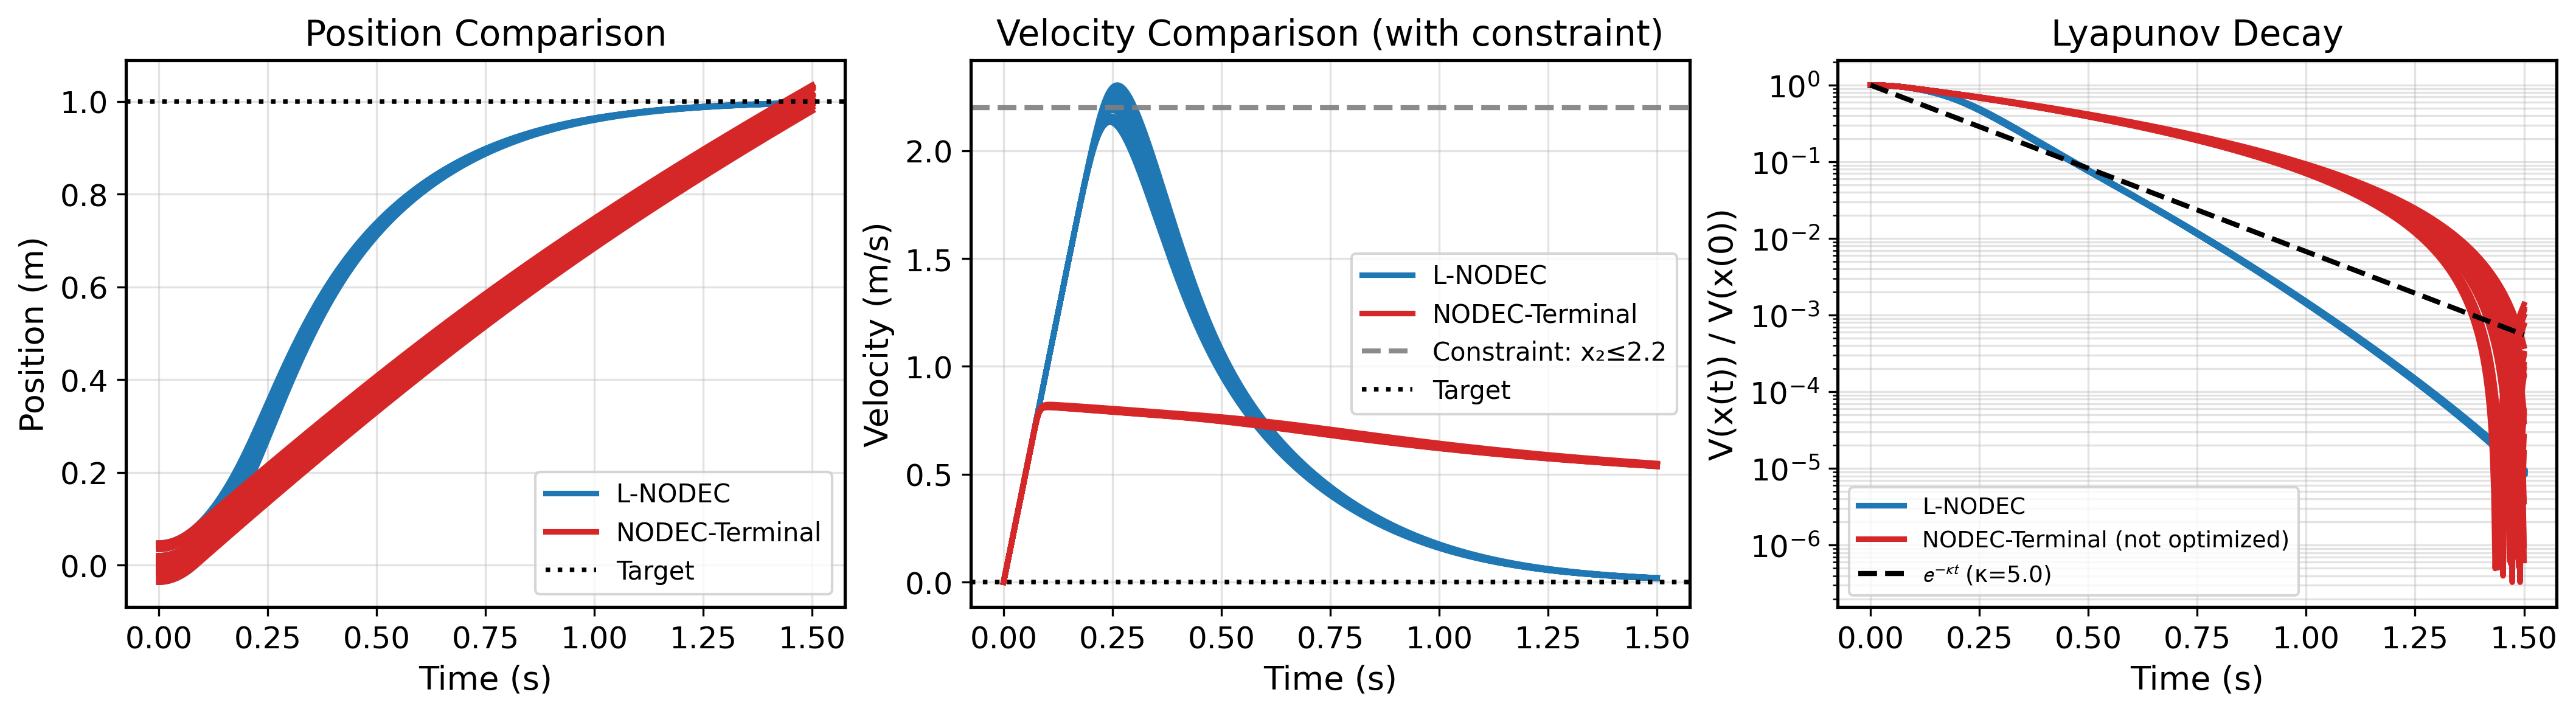

In [21]:
# (Optional) if you haven't already:
# set_plot_style()

alpha = 1

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

# Method colors (tab10): blue, green, red
colors_methods = {
    'L-NODEC': 'C0',
    'L-NODEC-Constrained': 'C2',
    'NODEC-Terminal': 'C3',
}

dict_all = {
    'L-NODEC': LNODEC_unconstrained_dict, # traj_lnodec,
    # 'L-NODEC-Constrained': LNODEC_constrained_dict, # traj_constrained,
    'NODEC-Terminal': NODEC_dict, # traj_terminal,
}

# --- Plot 1: Position ---
for method_name, data in dict_all.items():
    time_grid_np = data['time_grid_np']
    for i, traj in enumerate(data['trajectories']):
        axes[0].plot(
            time_grid_np, 
            traj[:, 0],
            color = colors_methods[method_name], 
            linewidth = 2.2, 
            label = method_name if i == 0 else None,
            alpha = alpha,
        )
axes[0].axhline(float(z_target[0]), color='black', linestyle=':', linewidth=1.8, label='Target')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('Position Comparison')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.35)

# --- Plot 2: Velocity (with constraint line) ---
for method_name, data in dict_all.items():
    time_grid_np = data['time_grid_np']
    for i, traj in enumerate(data['trajectories']):
        axes[1].plot(
            time_grid_np, 
            traj[:, 1],
            color = colors_methods[method_name], 
            linewidth = 2.2, 
            label = method_name if i == 0 else None,
            alpha = alpha,
        )
axes[1].axhline(x2_max, color='C7', linestyle='--', linewidth=2.0,
                label=f'Constraint: x₂≤{x2_max}', alpha=0.9)   # neutral-ish color to avoid confusion
axes[1].axhline(0, color='black', linestyle=':', linewidth=1.8, label='Target')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Velocity (m/s)')
axes[1].set_title('Velocity Comparison (with constraint)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.35)

# --- Plot 3: Lyapunov decay ---
eps = 1e-12
for method_name, data in dict_all.items():
    time_grid_np = data['time_grid_np']
    for i, traj in enumerate(data['trajectories']):
        V_traj = []
        for x in traj:
            x_torch = torch.tensor(x, dtype=torch.float32)
            V = lyapunov_fn.potential(x_torch, z_target).item()
            V_traj.append(V)
        V_traj = np.array(V_traj)
        V_norm = np.clip(V_traj / (V_traj[0] + eps), eps, None)  # log-safe
        label = method_name if 'L-NODEC' in method_name else f'{method_name} (not optimized)'
        axes[2].plot(
            time_grid_np, 
            V_norm,
            color = colors_methods[method_name], 
            linewidth = 2.2, 
            label = label if i == 0 else None,
            alpha = alpha,
        )

exp_bound = np.exp(-kappa * time_grid_np)
axes[2].plot(time_grid_np, exp_bound, 'k--', linewidth=2.0, label=fr'$e^{{-\kappa t}}$ (κ={kappa})')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('V(x(t)) / V(x(0))')
axes[2].set_title('Lyapunov Decay')
axes[2].set_yscale('log')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.35, which='both')

plt.show()


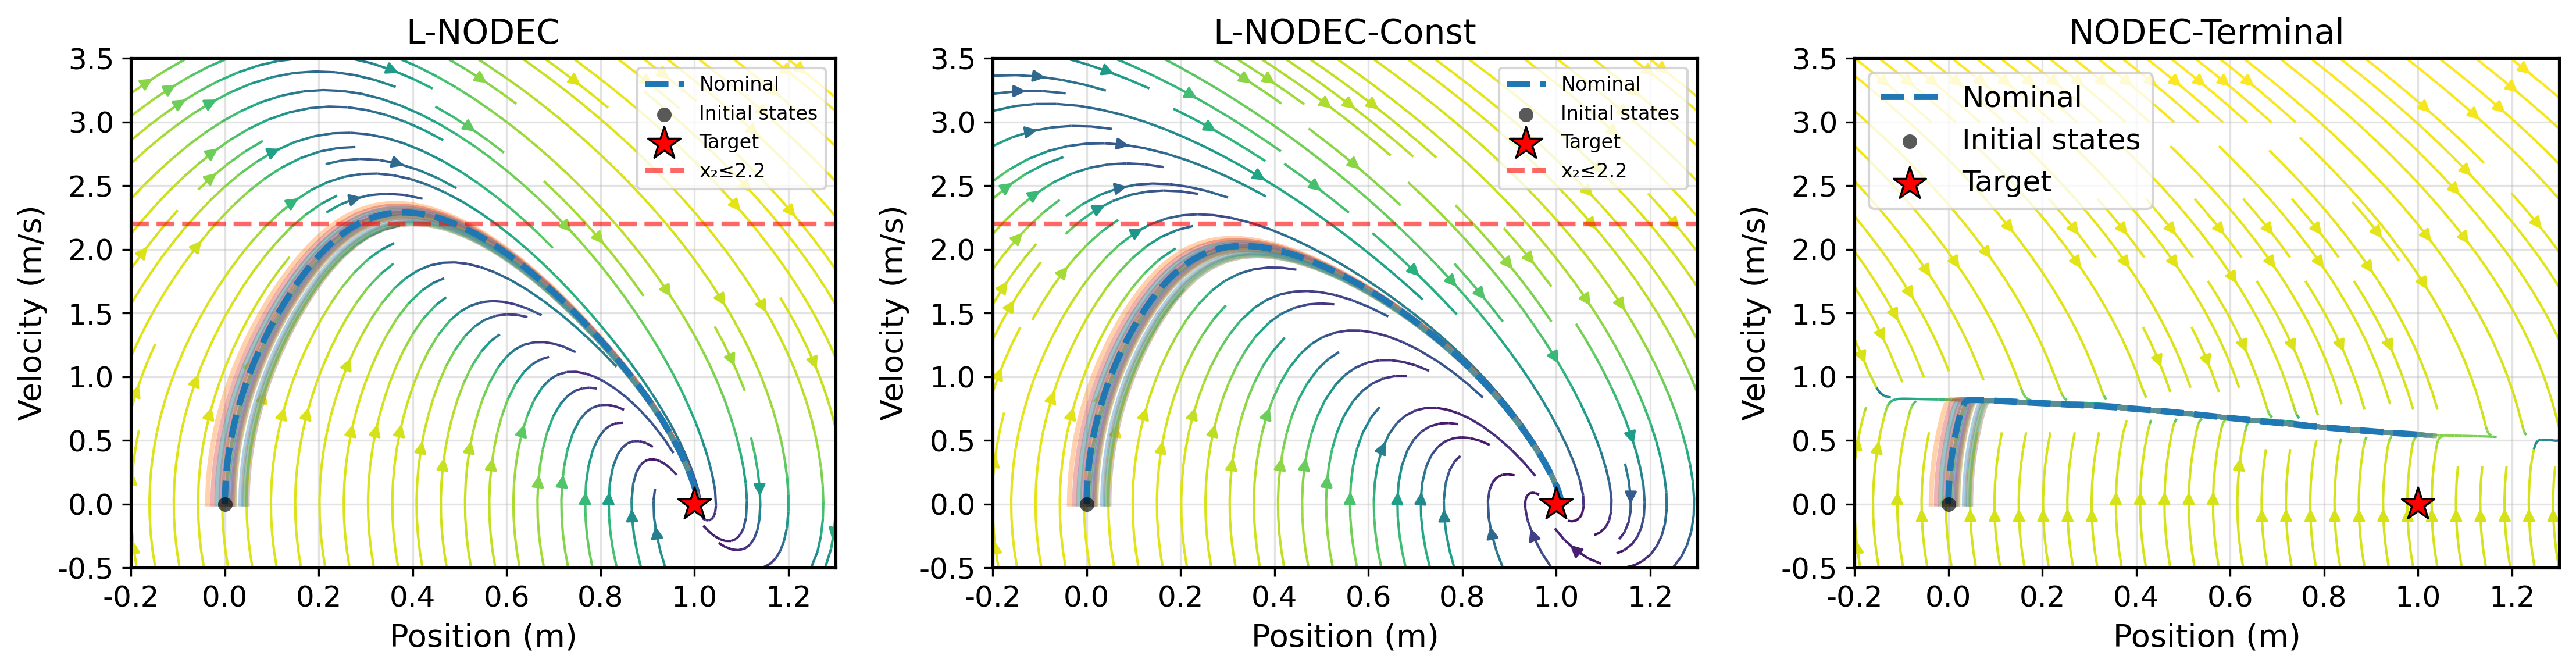

In [14]:
def compute_vector_field_for_policy(policy_to_use):
    """Helper to compute vector field for a specific policy"""
    def vf(X1, X2):
        U1 = np.zeros_like(X1)
        U2 = np.zeros_like(X2)
        for i in range(X1.shape[0]):
            for j in range(X1.shape[1]):
                x = torch.tensor([X1[i, j], X2[i, j]], dtype=dtype, device=device)
                with torch.no_grad():
                    u = policy_to_use(x)
                    xdot = double_integrator_dynamics(x, u, 0.0)
                U1[i, j] = xdot[0].item()
                U2[i, j] = xdot[1].item()
        return U1, U2
    return vf

# Create side-by-side phase portraits for all methods
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (method_name, policy_method, traj, x0_samples) in enumerate([
    ('L-NODEC', policy, dict_all['L-NODEC']['trajectories'], dict_all['L-NODEC']['x0_samples']),
    ('L-NODEC-Const', policy_constrained, dict_all['L-NODEC-Constrained']['trajectories'], dict_all['L-NODEC-Constrained']['x0_samples']),
    ('NODEC-Terminal', policy_terminal, dict_all['NODEC-Terminal']['trajectories'], dict_all['NODEC-Terminal']['x0_samples']),
]):
    plot_phase_portrait(
        axes[idx],
        trajectories=traj,
        initial_states=x0_samples[0].cpu().numpy().reshape(1, -1),
        final_states=traj[-1].reshape(1, -1),
        target_state=z_target,
        vector_field_fn=compute_vector_field_for_policy(policy_method),
        title=f'{method_name}',
        x1_lim=(-0.2, 1.3),
        x2_lim=(-0.5, 3.5),
    )
    
    # Add constraint line on phase portrait
    if 'Const' in method_name or idx == 0:  # Show on constrained and first plot
        axes[idx].axhline(x2_max, color='red', linestyle='--', linewidth=2, 
                         alpha=0.6, label=f'x₂≤{x2_max}')
        axes[idx].legend(fontsize=8, loc = 'upper right')

plt.tight_layout()
plt.show()